# Stellar Flare Light Curve Simulation Pipeline

This notebook demonstrates the two-stage pipeline for generating synthetic stellar flare light curves on Nancy Grace Roman Space Telescope cadences, using TESS observations as the source data.

In [1]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.table import Table
import george
from george import kernels
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from functions import rot_var_gp_fit, prep_input, flare_fit
from gp_model_params import info
from tqdm.notebook import tqdm
np.random.seed(42)

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [2]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 13,
    "axes.labelsize"   : 14,
    "axes.titlesize"   : 14,
    "legend.fontsize"  : 11,
    "xtick.direction"  : "in",
    "ytick.direction"  : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"       : 120,
})

# Colour palette (colour-blind friendly)
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [3]:
# Paths
home = str(Path.home())

# Directory containing the TESS flare FITS files
TESS_PATH   = home + '/Research_data/Bulge_Variables/Flares_TESS/'
OUTPUT_PLOT = 'output/plots/FL/'
OUTPUT_FILE = 'output/flares/'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)

tp   = 'Flares_TESS'
band = 'TESS'

In [78]:
def inject(t_arr, y_arr, t0, tmin_flare, tmax_flare, interp_flare, baseline_mag):
    """Inject the flare template onto array y_arr sampled at times t_arr."""
    mask = (t_arr > t0 - tmin_flare) & (t_arr < t0 + tmax_flare)
    if mask.sum() == 0:
        return y_arr
    t_local    = t_arr[mask] - t_arr[mask].min() + tmin_flare
    delta_mag  = interp_flare(t_local-t_local.min())
    # Shift so the maximum brightening aligns to t0 (peak = 0 delta mag)
    y_arr[mask] += delta_mag - baseline_mag
    return y_arr
    

## Load Roman Telescope Cadence Arrays

In [5]:
# Load pre-computed Roman Galactic Bulge cadence time arrays
Roman_sampling_short  = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long   = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2  = np.load('lc_example/roman_times_longcadence2.npy')


Roman_sampling_long   -= Roman_sampling_long.min()
Roman_sampling_long2  -= Roman_sampling_short.min()
Roman_sampling_short  -= Roman_sampling_short.min()

Roman_max_short_time = Roman_sampling_short.max()

t_base       = Roman_sampling_short
t_base_long  = Roman_sampling_long
t_base_long2 = Roman_sampling_long2

# Dense regular grid for smooth curve evaluation
t_regular = np.linspace(0, Roman_max_short_time, 750_000)

print(f"Short cadence  : {len(t_base):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence 1 : {len(t_base_long):,} pts  |  span = {t_base_long.max():.1f} d")
print(f"Long cadence 2 : {len(t_base_long2):,} pts  |  span = {t_base_long2.max():.1f} d")

Short cadence  : 50,700 pts  |  span = 982.0 d
Long cadence 1 : 1,704 pts  |  span = 981.8 d
Long cadence 2 : 1,704 pts  |  span = 981.9 d


## Load a Single TESS Flare-Star Light Curve

In [6]:
all_paths = np.sort(glob(TESS_PATH + '*.fits'))
print(f"Found {len(all_paths)} TESS flare FITS files.")

demo_path = all_paths[1]
tic_id    = demo_path.split('/')[-1].split('_')[0].split('c')[-1]

Found 68 TESS flare FITS files.


In [7]:
# light curve + flare header entries
with fits.open(demo_path) as hdul:
    header  = hdul[1].header
    hd_data = hdul[1].data

# Convert HDU table to a tidy DataFrame
df_lc = Table(hd_data).to_pandas()
df    = df_lc[["BTJD", "mag", "mag_err"]].rename(
    columns={"BTJD": "t", "mag": "m", "mag_err": "e"}
)

# Extract flare metadata from the FITS header using regex on key names
# Each detected flare has keys F{n}-EXT, F{n}-BTJD-PEAK, etc.
flare_nums = sorted({
    int(re.search(r"F(\d+)", k).group(1))
    for k in header.keys()
    if re.match(r"F\d+-EXT", k)
})

flares = [
    {
        "flare_id"  : n,
        "ext"       : header.get(f"F{n}-EXT"),
        "btjd_start": header.get(f"F{n}-BTJD-START"),
        "btjd_peak" : header.get(f"F{n}-BTJD-PEAK"),
        "btjd_stop" : header.get(f"F{n}-BTJD-STOP"),
        "mag_start" : header.get(f"F{n}-MAG-START"),
        "mag_peak"  : header.get(f"F{n}-MAG-PEAK"),
        "mag_stop"  : header.get(f"F{n}-MAG-STOP"),
    }
    for n in flare_nums
]
df_header = pd.DataFrame(flares)

t_obs, m_obs, e_obs = df.t.values, df.m.values, df.e.values

df_header.head()

,flare_id,ext,btjd_start,btjd_peak,btjd_stop,mag_start,mag_peak,mag_stop
0,1,1,2095.722896,2095.730303,2095.840027,10.248152,None,10.251543
1,2,1,2103.109531,2103.113234,2103.138697,10.254030,None,10.255319
2,3,1,2104.954208,2104.956523,2104.981060,10.250636,None,10.250287
3,4,1,2105.084300,2105.086152,2105.132449,10.243996,None,10.241586
4,5,1,2109.473400,2109.479650,2109.516455,10.245737,None,10.247958


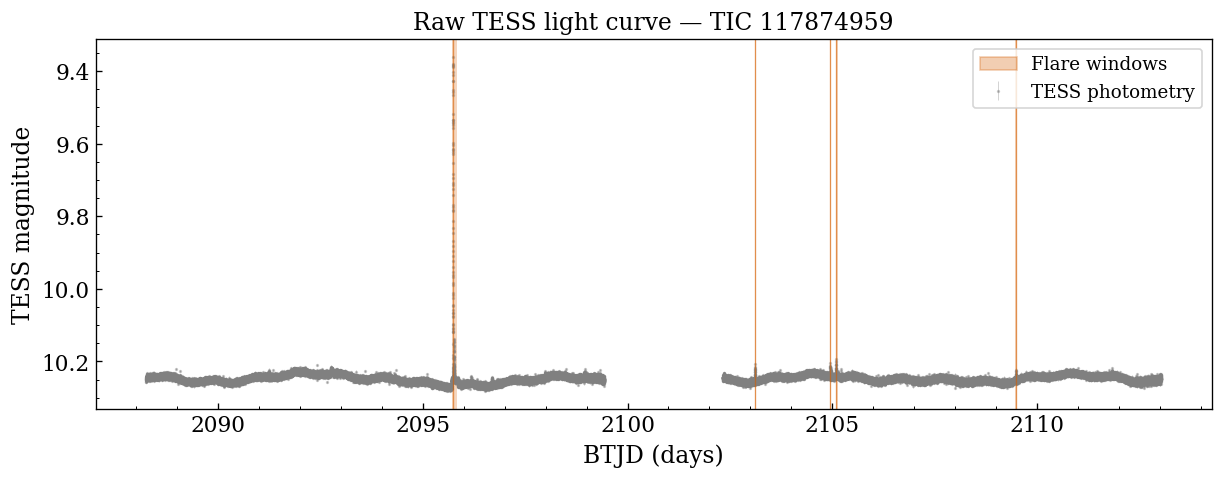

In [8]:
# Raw TESS light curve with flare windows highlighted
fig, ax = plt.subplots(figsize=(12, 4))

# Raw photometry
ax.errorbar(t_obs, m_obs, yerr=e_obs, fmt='.', color='grey',
            alpha=0.4, ms=2, lw=0.5, label='TESS photometry', zorder=1)

# Shade each catalogued flare window
for _, row in df_header.iterrows():
    ax.axvspan(row.btjd_start, row.btjd_stop,
               color=C3, alpha=0.25, lw=0)
    ax.axvline(row.btjd_peak, color=C3, lw=0.8, alpha=0.6)

# Dummy handle for the legend
ax.axvspan(np.nan, np.nan, color=C3, alpha=0.3, label='Flare windows')

ax.invert_yaxis()
ax.set_xlabel('BTJD (days)')
ax.set_ylabel('TESS magnitude')
ax.set_title(f'Raw TESS light curve — TIC {tic_id}')
ax.legend(loc='upper right')

## Gaussian Process Fit to the Quiescent Baseline

In [9]:
threshold_mag = -0.1 #np.percentile(y_binned, 10)
baseline_mag = np.percentile(m_obs, 50) # your quiescent magnitude
# y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
y_sim = m_obs.copy()
mask = (m_obs < baseline_mag+threshold_mag)

y_sim[mask] = np.ones_like(y_sim[mask]) * baseline_mag #+ np.random.normal(0, 0.001, size=len(y_sim[mask]))

y_sim = y_sim - np.median(y_sim)

In [10]:
# Fit the GP baseline model
print("Fitting GP baseline ...")
gp_base, data_base = rot_var_gp_fit(t_obs, y_sim, e_obs, n_bins=1000)

m_data, t_data, m_err = data_base[0], data_base[1], data_base[2]
print(f"GP fit complete. Binned data: {len(t_data)} points.")

Fitting GP baseline ...


/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


GP fit complete. Binned data: 884 points.


In [11]:
# Predict GP mean on the dense regular grid
y_base_regular, y_var_regular = gp_base.predict(m_data, t_regular, return_var=True)
y_base_regular_std = np.sqrt(y_var_regular)   # 1-sigma uncertainty band

interp_baseline = interp1d(
    t_regular, y_base_regular,
    kind='linear', bounds_error=False, fill_value=np.nan
)
y_base       = interp_baseline(t_base)        # short cadence
y_base_long  = interp_baseline(t_base_long)   # long cadence 1
y_base_long2 = interp_baseline(t_base_long2)  # long cadence 2

(0.0, 20.0)

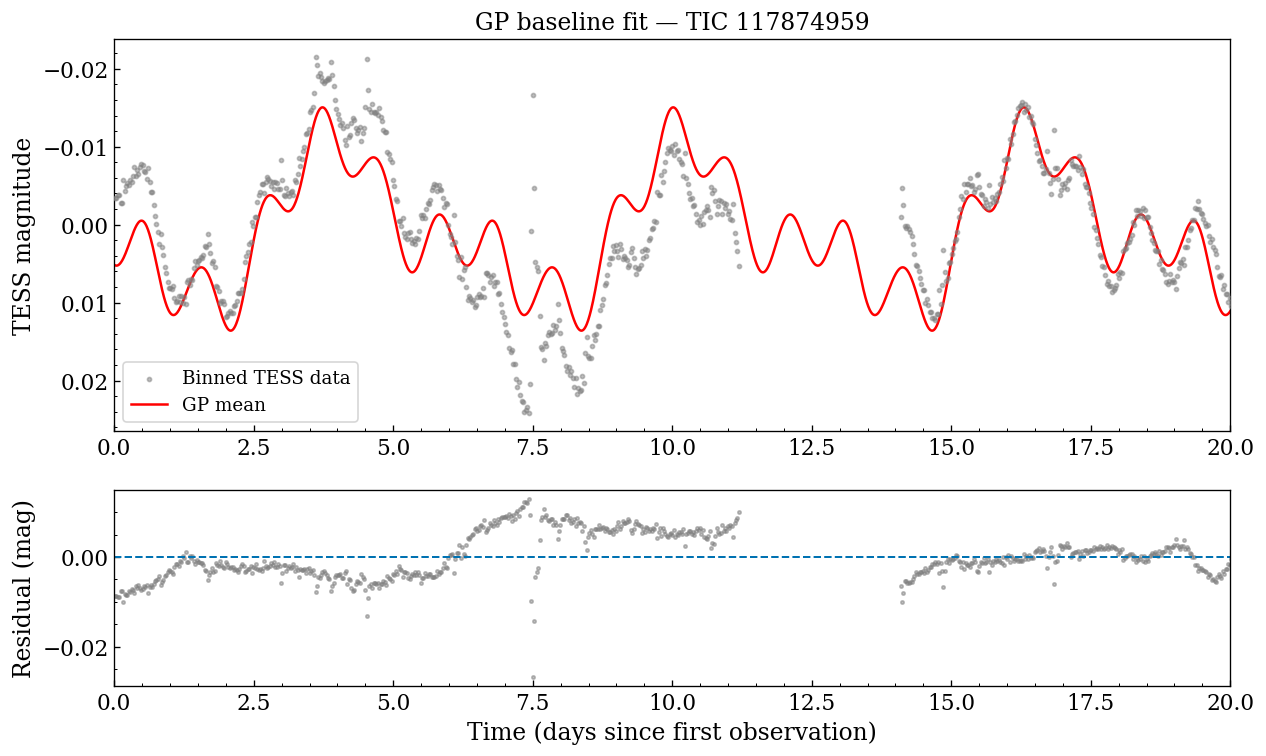

In [12]:
# GP baseline fit — full time series and close-up
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={'height_ratios': [2, 1]})

ax = axes[0]
ax.scatter(t_data, m_data, s=6, alpha=0.5, color='grey',
           label='Binned TESS data', zorder=3)
ax.plot(t_base, y_base, color="red", lw=1.5, label="GP mean")

# ax.plot(t_regular, y_base_regular, color=C0, lw=1.5, label='GP mean', zorder=4)
# ax.fill_between(
#     t_regular,
#     y_base_regular - y_base_regular_std,
#     y_base_regular + y_base_regular_std,
#     color=C0, alpha=0.2, label=r'GP $1\sigma$'
# )
ax.set_xlim(0, 20)  
ax.invert_yaxis()
ax.set_ylabel('TESS magnitude')
ax.set_title(f'GP baseline fit — TIC {tic_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax2 = axes[1]
interp_at_data = interp1d(
    t_base, y_base,
    kind='linear', bounds_error=False, fill_value=np.nan
)
residuals = m_data - interp_at_data(t_data)
ax2.scatter(t_data, residuals, s=4, alpha=0.5, color='grey')
ax2.axhline(0, color=C0, lw=1.2, ls='--')
ax2.set_xlabel('Time (days since first observation)')
ax2.set_ylabel('Residual (mag)')
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.set_xlim(0, 20)

## GP Fit to Individual Flares

In [13]:
# Fit GP templates to each flare in the demo light curve
info_copy   = info[tp].copy()
period      = np.nan   # no known rotation period for this source

flare_dics  = {}   # store all flare GP dictionaries keyed by flare id

for _, row in tqdm(df_header.iterrows(), total=len(df_header),
                   desc='Fitting individual flares'):
    f = int(row.flare_id)

    # Skip flares whose peak falls outside the observed baseline
    if row.btjd_peak > df.t.max():
        print(f"  Flare {f}: peak outside time range — skipping.")
        continue

    # Clip light curve to the flare window
    df_fl = df[(df.t < row.btjd_stop) & (df.t > row.btjd_start)].copy()

    # Shift flare window to start at t = 0
    if df_fl.t.min() > 0:
        df_fl['t'] = df_fl['t'] - df_fl['t'].min()

    # Prepare inputs: baseline subtraction, rescaling to Roman dynamic range
    x_fl, y_fl, e_fl = prep_input(df_fl, tp, period, info_copy, Roman_max_short_time)

    # Fit GP to the isolated, rescaled flare
    dic = flare_fit(x_fl, y_fl, e_fl, info_copy, period)
    flare_dics[f] = dic

Fitting individual flares:   0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 1.01, 'Individual Flare GP Templates — TIC 117874959')

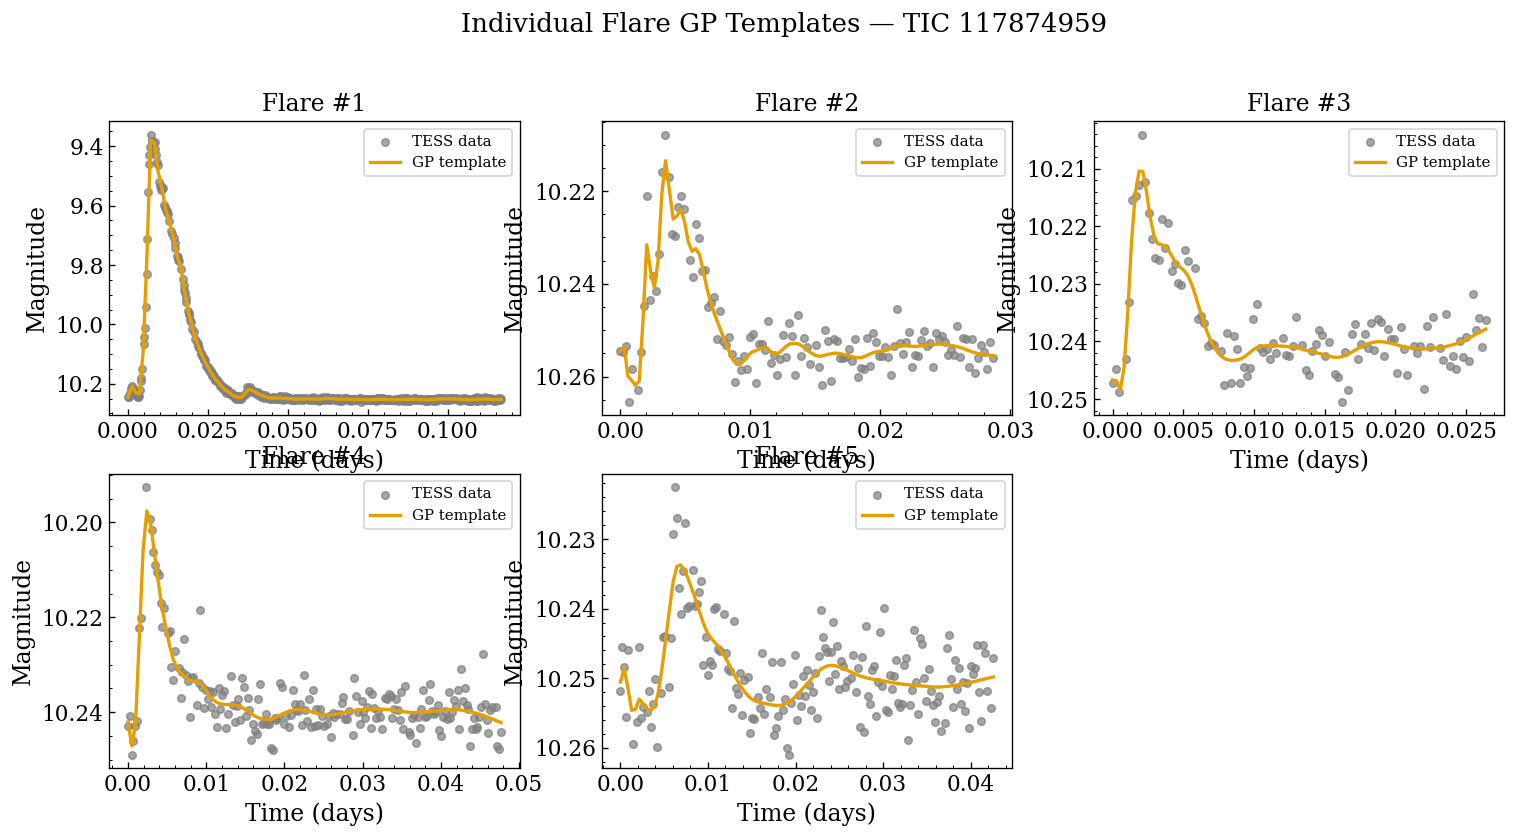

In [54]:
# Gallery of individual flare GP fits

fids   = list(flare_dics.keys())[:6]
n_show = len(fids)
ncols  = min(3, n_show)
nrows  = int(np.ceil(n_show / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows),
                         sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, f in zip(axes, fids):
    dic = flare_dics[f]

    ax.scatter(dic['x'], dic['y'], s=20, color='grey', alpha=0.7,
               zorder=3, label='TESS data')

    ax.plot(dic['x_new'], dic['y_new'], color=C1, lw=2,
            label='GP template', zorder=4)

    ax.invert_yaxis()
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'Flare #{f}')
    ax.legend(fontsize=9)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

for ax in axes[n_show:]:
    ax.set_visible(False)

fig.suptitle(f'Individual Flare GP Templates — TIC {tic_id}', y=1.01)

## Light Curve Generation

In [15]:
# Build minimal single-entry banks from the demo star

baseline_bank_demo = {
    tic_id: {
        f'{band}_band_Roman_m_official_sampling_short'  : y_base,
        f'{band}_band_Roman_m_official_sampling_long'   : y_base_long,
        f'{band}_band_Roman_m_official_sampling_long2'  : y_base_long2,
        f'{band}_band_Roman_m_regular_sampling'         : y_base_regular,
        f'{band}_band_Roman_time_regular_sampling'      : t_regular,
    }
}

flare_bank_demo = {
    f'{tic_id}_{fid}': flare_dics[fid]
    for fid in flare_dics
}

print(f"Baseline bank entries : {len(baseline_bank_demo)}")
print(f"Flare bank entries    : {len(flare_bank_demo)}")

Baseline bank entries : 1
Flare bank entries    : 5


In [85]:
# Simulate one Roman light curve with a chosen number of injected flares

N_INJECT = min(5, len(flare_bank_demo))   # inject up to 5 flares for the demo

y_sim        = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_short'].copy()
y_sim_long   = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_long'].copy()
y_sim_long2  = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_long2'].copy()
y_sim_reg    = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_regular_sampling'].copy()
t_reg        = baseline_bank_demo[tic_id][f'{band}_band_Roman_time_regular_sampling']

# Randomly choose injection times and flare templates
flare_keys      = list(flare_bank_demo.keys())
chosen_keys     = np.random.choice(flare_keys, size=N_INJECT, replace=False)
injection_times = np.random.choice(t_base_long, size=N_INJECT, replace=False)-0.01

injected_info = []  # record injection metadata for annotations

for key, t0 in zip(chosen_keys, injection_times):
    flare = flare_bank_demo[key]

    # Locate the peak of the flare template (minimum magnitude = brightest point)
    flare_tmax = flare['x'][np.argmin(flare['yfit'])]
    tmin_flare = flare_tmax - flare['x'].min()   # duration before peak
    tmax_flare = flare['x'].max() - flare_tmax   # duration after peak

    # Build a linear interpolator for the smooth GP template
    interp_flare = interp1d(
        flare['x_new'], flare['y_new'],
        kind='linear', bounds_error=False, fill_value=np.nan
    )
    baseline_mag = np.max(flare['y_new'])
    y_sim = inject(t_base,      y_sim, t0, tmin_flare, tmax_flare, interp_flare, baseline_mag)
    y_sim_long = inject(t_base_long, y_sim_long, t0, tmin_flare, tmax_flare, interp_flare, baseline_mag)
    y_sim_long2 = inject(t_base_long2, y_sim_long2, t0, tmin_flare, tmax_flare, interp_flare, baseline_mag)
    y_sim_reg = inject(t_reg,       y_sim_reg, t0, tmin_flare, tmax_flare, interp_flare, baseline_mag)

    injected_info.append({'key': key, 't0': t0,
                          'duration_days': tmin_flare + tmax_flare})

print(f"Injected {N_INJECT} flares.")
pd.DataFrame(injected_info)

Injected 5 flares.


,key,t0,duration_days
0,117874959_3,947.24,0.026389
1,117874959_2,416.99,0.028704
2,117874959_1,14.99,0.116668
3,117874959_4,768.49,0.047685
4,117874959_5,609.49,0.042592


## Plot the Simulated Light Curve

Text(0.5, 0.92, 'Roman Light Curve resampled from TIC 117874959 with 5 injected flares')

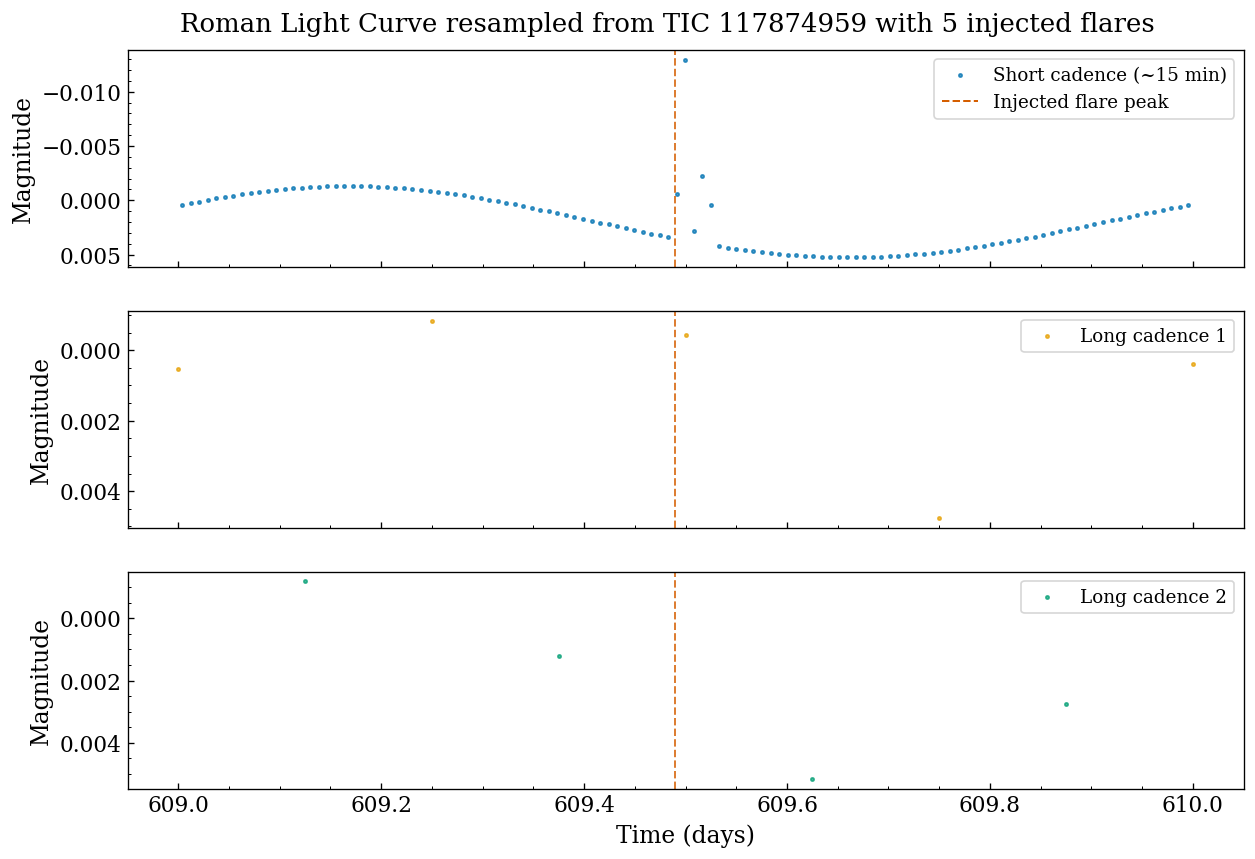

In [87]:
PLOT_WIN = (609, 610)   # days

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

cadences = [
    (t_base,       y_sim,       'Short cadence (~15 min)', C0),
    (t_base_long,  y_sim_long,  'Long cadence 1',          C1),
    (t_base_long2, y_sim_long2, 'Long cadence 2',          C2),
]

for ax, (t_arr, y_arr, label, col) in zip(axes, cadences):
    mask = (t_arr >= PLOT_WIN[0]) & (t_arr <= PLOT_WIN[1])
    ax.scatter(t_arr[mask], y_arr[mask], s=4, alpha=0.7, color=col, label=label)

    # Mark injection times that fall within the plot window
    for info_j in injected_info:
        t0 = info_j['t0']
        if PLOT_WIN[0] < t0 < PLOT_WIN[1]:
            ax.axvline(t0, color=C3, lw=1.2, ls='--', alpha=0.8)

    ax.invert_yaxis()
    ax.set_ylabel('Magnitude')
    ax.legend(loc='upper right')
    ax.xaxis.set_minor_locator(AutoMinorLocator())

axes[0].axvline(np.nan, color=C3, lw=1.2, ls='--', label='Injected flare peak')
axes[0].legend(loc='upper right')

axes[-1].set_xlabel('Time (days)')
fig.suptitle(f'Roman Light Curve resampled from TIC {tic_id} with {N_INJECT} injected flares',
             y=0.92)

# axes[0].set_xlim(227.5, 228.5)
# axes[1].set_xlim(227.5, 228.5)
# axes[2].set_xlim(227.5, 228.5)

Text(0.5, 1.01, 'Zoom: Injected Flare at $t_0$ = 583.80 d')

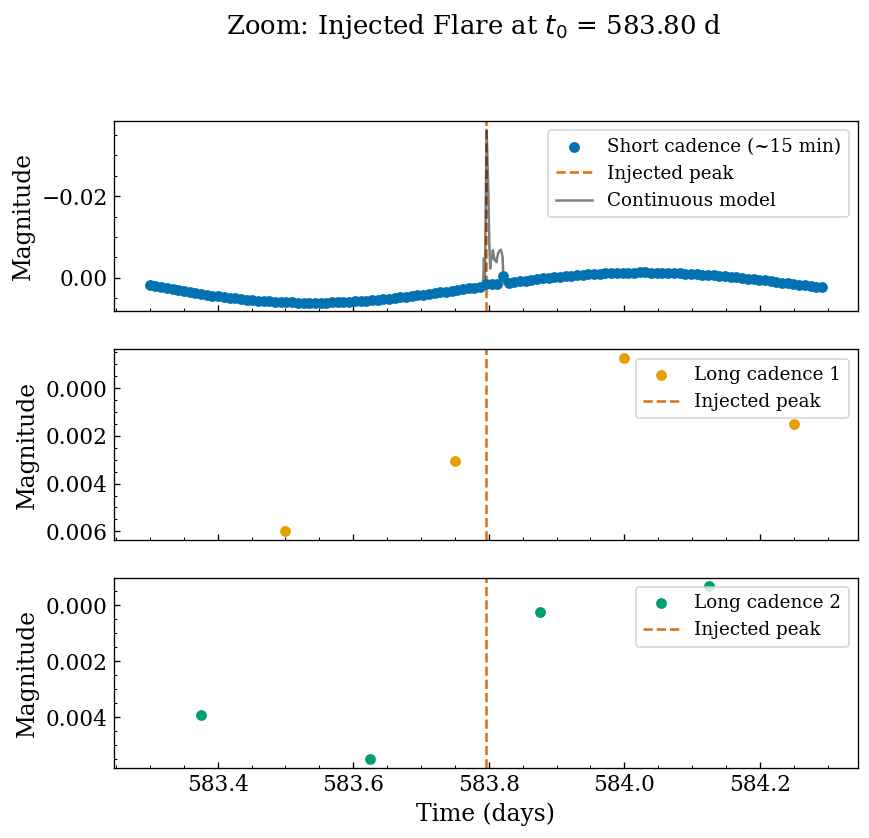

In [47]:
# Zoom into one injected flare at all cadences

mid   = 0.5 * (PLOT_WIN[0] + PLOT_WIN[1])
t0_zoom = min(injected_info, key=lambda d: abs(d['t0'] - mid))['t0']
ZOOM  = (t0_zoom - 0.5, t0_zoom + 0.5)

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

for ax, (t_arr, y_arr, label, col) in zip(axes, cadences):
    mask = (t_arr >= ZOOM[0]) & (t_arr <= ZOOM[1])
    ax.scatter(t_arr[mask], y_arr[mask], s=30, color=col, zorder=3, label=label)
    ax.axvline(t0_zoom, color=C3, lw=1.5, ls='--', alpha=0.9, label='Injected peak')
    ax.invert_yaxis()
    ax.set_ylabel('Magnitude')
    ax.legend(loc='upper right')
    ax.xaxis.set_minor_locator(AutoMinorLocator())

# Overlay the dense regular-grid curve on the top panel for reference
mask_reg = (t_reg >= ZOOM[0]) & (t_reg <= ZOOM[1])
axes[0].plot(t_reg[mask_reg], y_sim_reg[mask_reg],
             color='black', lw=1.5, alpha=0.5, ls='-', zorder=2,
             label='Continuous model')
axes[0].legend(loc='upper right')

axes[-1].set_xlabel('Time (days)')
fig.suptitle(f'Zoom: Injected Flare at $t_0$ = {t0_zoom:.2f} d', y=1.01)


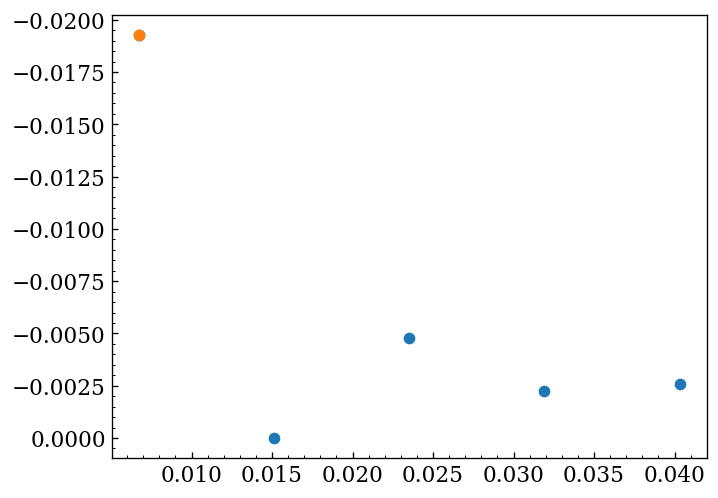

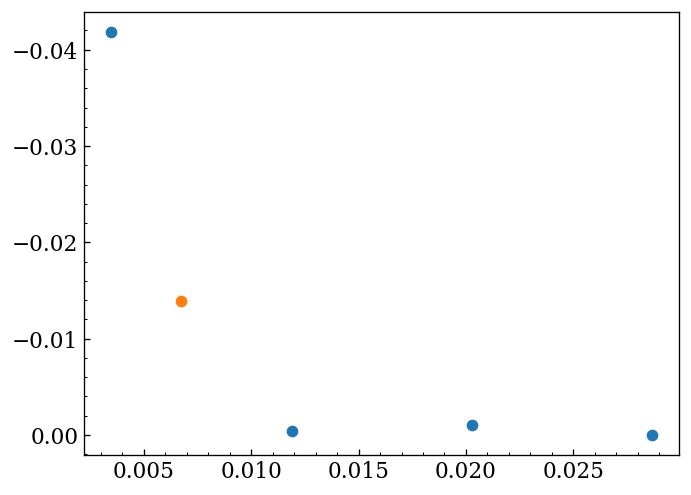

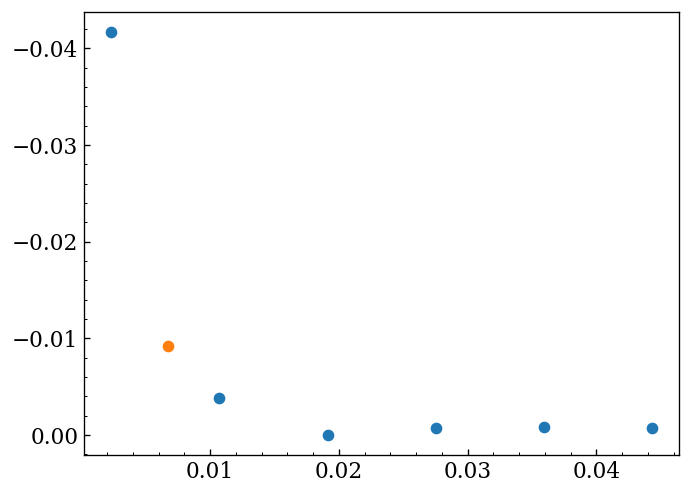

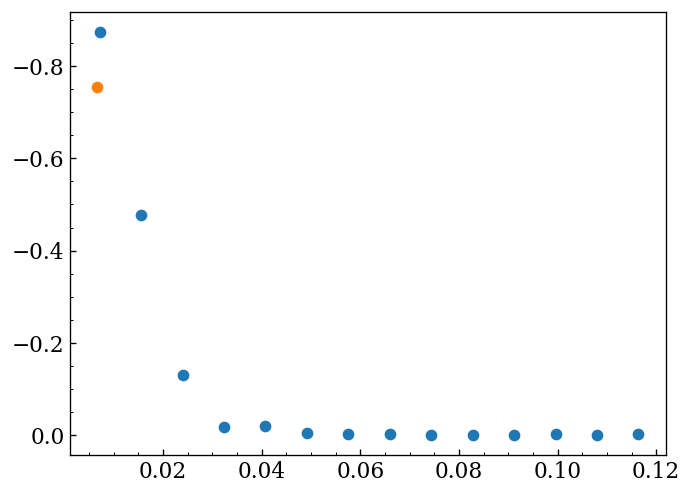

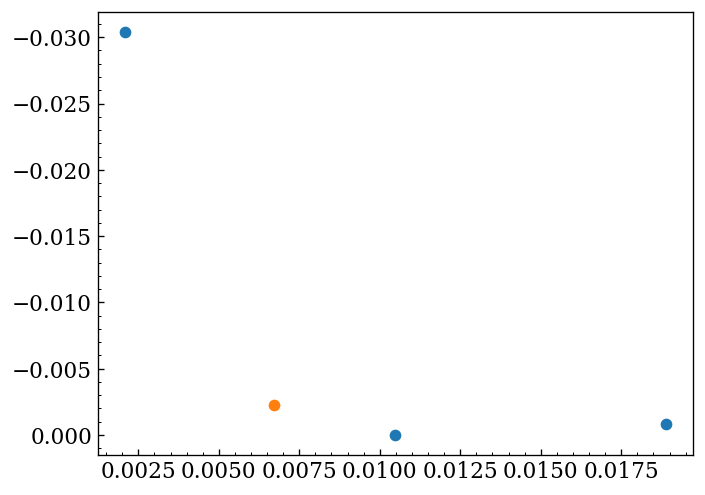

In [77]:
# Simulate one Roman light curve with a chosen number of injected flares

N_INJECT = min(5, len(flare_bank_demo))   # inject up to 5 flares for the demo

y_sim        = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_short'].copy()
y_sim_long   = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_long'].copy()
y_sim_long2  = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_official_sampling_long2'].copy()
y_sim_reg    = baseline_bank_demo[tic_id][f'{band}_band_Roman_m_regular_sampling'].copy()
t_reg        = baseline_bank_demo[tic_id][f'{band}_band_Roman_time_regular_sampling']

# Randomly choose injection times and flare templates
flare_keys      = list(flare_bank_demo.keys())
chosen_keys     = np.random.choice(flare_keys, size=N_INJECT, replace=False)
injection_times = np.random.choice(t_base, size=N_INJECT, replace=False)

injected_info = []  # record injection metadata for annotations

for key, t0 in zip(chosen_keys, injection_times):
    flare = flare_bank_demo[key]

    # Locate the peak of the flare template (minimum magnitude = brightest point)
    flare_tmax = flare['x'][np.argmin(flare['yfit'])]
    tmin_flare = flare_tmax - flare['x'].min()   # duration before peak
    tmax_flare = flare['x'].max() - flare_tmax   # duration after peak

    # Build a linear interpolator for the smooth GP template
    interp_flare = interp1d(
        flare['x_new'], flare['y_new'],
        kind='linear', bounds_error=False, fill_value=np.nan
    )



    mask = (t_base > t0 - tmin_flare) & (t_base < t0 + tmax_flare)
    if mask.sum() == 0:
        continue
    t_local    = t_base[mask] - t_base[mask].min() + tmin_flare
    delta_mag  = interp_flare(t_local)
    # Shift so the maximum brightening aligns to t0 (peak = 0 delta mag)
    y_sim[mask] += delta_mag - np.nanmax(delta_mag)


    mask_long = (t_base_long > t0 - tmin_flare-0.01) & (t_base_long < t0 + tmax_flare-0.01)
    if not mask_long.sum() == 0:
        
        t_local_long    = t_base_long[mask_long] - t_base_long[mask_long].min() + tmin_flare
        delta_mag  = interp_flare(t_local_long)
        # Shift so the maximum brightening aligns to t0 (peak = 0 delta mag)
        y_sim_long[mask_long] += delta_mag - np.nanmax(interp_flare(t_local))

    # y_sim = inject(t_base,      y_sim, t0, tmin_flare, tmax_flare, interp_flare)
    # y_sim_long = inject(t_base_long, y_sim_long, t0, tmin_flare, tmax_flare, interp_flare)
    # y_sim_long2 = inject(t_base_long2, y_sim_long2, t0, tmin_flare, tmax_flare, interp_flare)
    # y_sim_reg = inject(t_reg,       y_sim_reg, t0, tmin_flare, tmax_flare, interp_flare)

    injected_info.append({'key': key, 't0': t0,
                          'duration_days': tmin_flare + tmax_flare})

    plt.figure()
    # plt.scatter(flare['x_new'], flare['y_new'])
    # plt.plot(flare['x_new'], interp_flare(flare['x_new']))
    plt.scatter(t_local, interp_flare(t_local)-np.max(interp_flare(t_local)))
    plt.scatter(t_local_long, interp_flare(t_local_long)-np.max(interp_flare(t_local)))
    # plt.plot(t_base[mask], y_sim[mask],
    #          color='black', lw=1.5, alpha=0.5, ls='-', zorder=2,
    #          label='Continuous model')
    plt.gca().invert_yaxis()




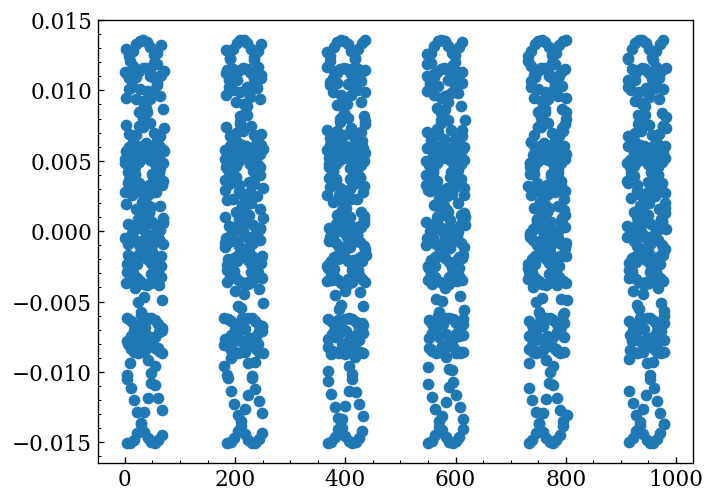

In [68]:
plt.scatter(t_base_long, y_sim_long)

In [66]:
np.nanmax(delta_mag)

np.float64(10.246691525304868)